# Demo — Spektralno klasterovanje i segmentacija slika pomoću grafova

Ova sveska daje brz, sažet pregled funkcionalnosti celog projekta — bez detaljnih eksperimenata i objašnjenja, koja se nalaze u prethodnim sveskama:

- `01_intro_i_teorija.ipynb` — teorijska pozadina algoritma
- `02_synthetic_data.ipynb` — poređenje sa k-means na sintetičkim podacima
- `03_image_segmentation.ipynb` — detaljna analiza segmentacije na pet slika
- `04_evaluation.ipynb` — poređenje sa baseline metodom i kvantitativna evaluacija na BSDS500

Ovde samo demonstriramo da pipeline radi, od početka do kraja, na dva tipa problema: klasterovanje tačaka i segmentacija slike.

In [6]:
import sys
sys.path.append('../src')

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from skimage import io
from skimage.segmentation import slic, mark_boundaries

from spectral import spectral_clustering
from image_utils import compute_superpixel_features, build_image_similarity_matrix
from spectral import spectral_clustering_from_similarity

ImportError: cannot import name 'spectral_clustering_from_similarity' from 'spectral' (C:\Users\BOJANA\Desktop\spectral-clustering-image-segmentation\notebooks\../src\spectral.py)

## 1. Klasterovanje sintetičkih podataka

Spektralno klasterovanje primenjeno na klasičan primer gde k-means ne uspeva — dva isprepletana polumeseca.

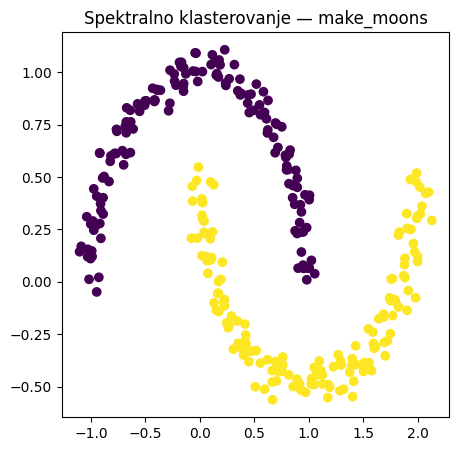

In [3]:
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
labels = spectral_clustering(X, k=2, sigma=0.2, normalized=True)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Spektralno klasterovanje — make_moons')
plt.show()

## 2. Segmentacija slike

Ista osnovna ideja (graf → Laplasijan → sopstveni vektori → k-means), primenjena na sliku preko SLIC superpiksela.

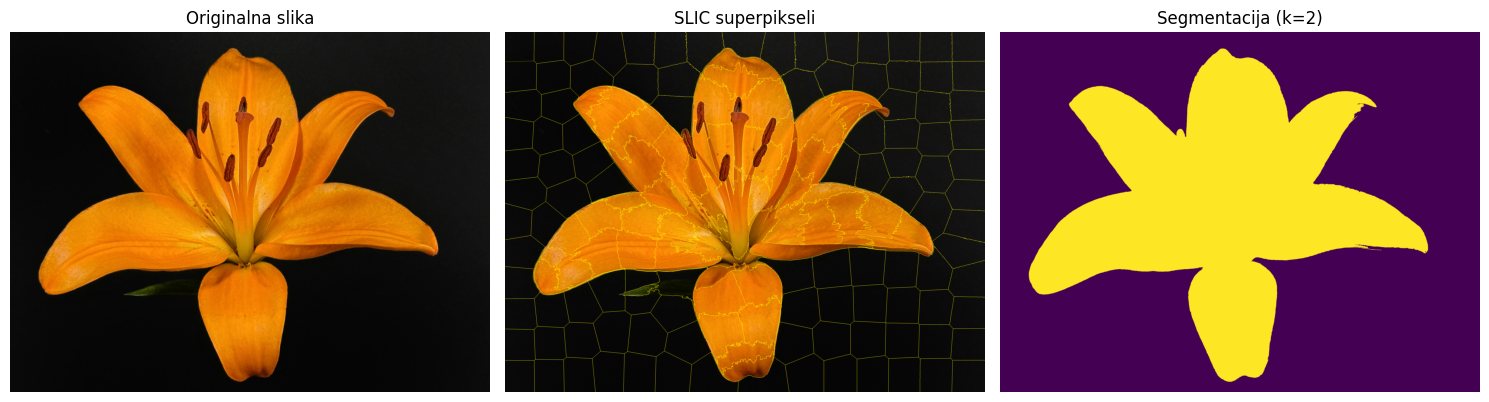

In [4]:
image = io.imread('../data/sample_images/yellow_lilly.jpg')
segments = slic(image, n_segments=200, compactness=10, start_label=0)
colors, positions = compute_superpixel_features(image, segments)

W = build_image_similarity_matrix(colors, positions, sigma_color=20, sigma_position=50)
labels = spectral_clustering_from_similarity(W, k=2, normalized=True)
segmented_image = labels[segments]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title('Originalna slika')
axes[0].axis('off')

axes[1].imshow(mark_boundaries(image, segments))
axes[1].set_title('SLIC superpikseli')
axes[1].axis('off')

axes[2].imshow(segmented_image, cmap='viridis')
axes[2].set_title('Segmentacija (k=2)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Rezime

Implementiran je kompletan pipeline za spektralno klasterovanje, primenjiv i na obične podatke (tačke u ravni) i na segmentaciju slika (preko superpiksela). Detaljna analiza, sistematični eksperimenti sa hiperparametrima, poređenje sa baseline metodom, i kvantitativna evaluacija na BSDS500 dostupni su u prethodnim sveskama — glavni nalazi su rezimirani u README.md.